# Tutorial 3: Random gen with explicit control + ensemble analysis

## Position relative to Tutorial 2

Tutorial 2 demonstrated the **auto-only** path: composition is the only input, every other knob (minsep, density, target CN, oxidation state) is derived from Shannon radii and class rules. That path is the right default when you don't have system-specific data.

This tutorial covers the **opposite end** of the same module — fully explicit control — and shows what to do when you *do* have system-specific data (crystal-phase bond lengths, measured amorphous densities, or a literature reference you want to reproduce).

| Aspect | Tutorial 2 (auto) | Tutorial 3 (explicit) |
|---|---|---|
| Inputs | `composition` only | `composition` + `target_density` + `minsep` per pair |
| Density source | Class-aware sphere packing | Cited experimental amorphous-thin-film values |
| Minsep source | Shannon radii × class scale factor | Shortest M–O / M–M / O–O distances in the crystalline phase |
| Per-system count | 1 structure (showcase) | 5 structures (ensemble for distribution statistics) |
| Analysis depth | Qualitative landing-near-target check | Quantitative: mean ± std RDF, energy scatter, CN + bond-angle histograms vs crystalline reference |
| Backend used | CHGNet on CPU (fast) | MACE-MPA-0 (higher accuracy for the oxide ensemble study) |

## When to use this explicit path

- You have an experimental amorphous density for the specific composition and want to anchor the cell volume to it (rather than the ~±20% sphere-packing estimate).
- You want to deliberately permit or forbid specific bonding configurations — e.g. tightening O–O minsep to suppress peroxide-like motifs, or loosening it to study them.
- You're benchmarking against a published reference and need to match its starting density and bond geometry exactly.
- You need an ensemble (5-20 structures) for distribution statistics rather than a single representative structure.

## What this tutorial covers

Four oxide systems (**In₂O₃**, **TiO₂**, **Al₂O₃**, **Ga₂O₃**) each generated as a 5-structure ensemble:

- **Section 1.1** — Define explicit minsep values from crystalline bond lengths and explicit target densities from amorphous-thin-film references (table cited inline). Generate 5 structures per system, save each in extxyz / cif / vasp, plot RDFs with mean ± individual-seed bands.
- **Section 1.2** — Relax the In₂O₃ ensemble with MACE-MPA-0 + UnitCellFilter (positions + cell), inspect the per-structure energy distribution, the relaxed RDF, the In–O coordination histogram, and the O–In–O bond-angle distribution. All compared against the bixbyite crystalline reference (CN=6, octahedral 90° / 180°).
- **CLI equivalents and the link to the full melt-quench pipeline** (Tutorial 4).

**Estimated wall time on CPU**: ~5 min for placement + ~10–15 min for the MACE relaxation step (CPU; GPU brings the relax step to under a minute).

**Prerequisites**:
- AmorphGen + a backend (`pip install amorphgen mace-torch`)
- `matplotlib` for the analysis plots

In [1]:
# Install AmorphGen if needed (uncomment one):
#   pip install amorphgen          # from PyPI (when published)
#   pip install -e ../..           # editable install from local repo
#
# Plus a backend (CHGNet for fast CPU; MACE for higher accuracy):
#   pip install chgnet
#   pip install mace-torch
#   pip install matplotlib         # for the plotting cells below

---
## 1.1 Generate random structures

This step places atoms randomly in a cubic box, respecting minimum separation
constraints between atom pairs. No force field or GPU is needed — this is
pure geometry.

Key parameters:
- **composition**: number of each atom type
- **target_density**: experimental amorphous density in g/cm³ (sets the box size)
- **minsep**: minimum allowed distance between each pair of species (in Å)

### Define the oxide systems

**Minimum separation (minsep)** values are derived from the shortest M–O bond
lengths in the crystalline phases. These act as hard-sphere exclusion radii to
prevent unphysical atom overlaps:

| System | Crystal phase | M–O bond (Å) | M–M dist (Å) | O–O dist (Å) | Source |
|--------|-------------|--------------|--------------|--------------|--------|
| In₂O₃ | Bixbyite | 2.13–2.23 | 3.34 | ~2.7 | Materials Project mp-22598 |
| TiO₂ | Rutile/Anatase | 1.93–1.98 | 3.04 | ~2.5 | Materials Project mp-2657 |
| Al₂O₃ | Corundum (α) | 1.85–1.97 | 2.65 | ~2.5 | Materials Project mp-1143 |
| Ga₂O₃ | Monoclinic (β) | 1.84–2.08 | 3.04 | ~2.6 | Materials Project mp-886 |

**Target density** is set 10–30% below the crystalline density, consistent
with experimental measurements of amorphous thin films:

| System | Crystal ρ (g/cm³) | Amorphous ρ (g/cm³) | Reduction | Source |
|--------|------------------|--------------------|-----------|---------|
| In₂O₃ | 7.12 | 5.4–6.0 | ~16–24% | Buchholz et al. 2014; Nakamura et al. Sci. Rep. 2025 |
| TiO₂ | 3.84 (anatase) | 2.9–3.6 | ~6–25% | Laube et al. Thin Solid Films 1999 |
| Al₂O₃ | 3.99 (corundum) | 2.8–3.2 | ~20–30% | Gorham et al. Thin Solid Films 2018 |
| Ga₂O₃ | 5.88 (β) | 3.9–4.8 | ~18–34% | Wang et al. J. Electron. Mater. 2025 |

In [2]:
# Define 4 oxide systems with scientifically justified parameters
#
# minsep: derived from shortest M-O bonds in the crystalline phase
#         (see table above for references)
#         Reduced slightly from crystalline values to allow efficient packing
# target_density: ~10-20% below crystalline density,
#                 matching experimental amorphous thin film values

systems = {
    "In2O3": {
        "composition": {"In": 16, "O": 24},    # 40 atoms, In:O = 2:3
        "target_density": 5.5,                   # g/cm3 — crystal: 7.12, ~17% reduction
        "minsep": {                              # Buchholz et al. Chem. Mater. 2014
            "In-In": 2.8,                        # crystal In-In: 3.34 A (reduced for packing)
            "In-O":  1.9,                        # crystal In-O:  2.13-2.23 A
            "O-O":   2.5,                        # crystal O-O:   ~2.7 A
        },
    },
    "TiO2": {
        "composition": {"Ti": 12, "O": 24},     # 36 atoms, Ti:O = 1:2
        "target_density": 3.0,                   # g/cm3 — crystal: 3.84 (anatase), ~11% reduction
        "minsep": {                              # rutile/anatase bond lengths
            "Ti-Ti": 2.8,                        # crystal Ti-Ti: 3.04 A
            "Ti-O":  1.7,                        # crystal Ti-O:  1.93-1.98 A
            "O-O":   2.3,                        # crystal O-O:   ~2.5 A
        },
    },
    "Al2O3": {
        "composition": {"Al": 16, "O": 24},     # 40 atoms, Al:O = 2:3
        "target_density": 2.6,                   # g/cm3 — crystal: 3.99 (corundum), ~20% reduction
        "minsep": {                              # corundum (alpha-Al2O3) bond lengths
            "Al-Al": 2.4,                        # crystal Al-Al: 2.65 A
            "Al-O":  1.6,                        # crystal Al-O:  1.85-1.97 A
            "O-O":   2.3,                        # crystal O-O:   ~2.5 A
        },
    },
    "Ga2O3": {
        "composition": {"Ga": 16, "O": 24},     # 120 atoms, Ga:O = 2:3
        "target_density": 4.2,                   # g/cm3 — crystal: 5.88 (beta), ~20% reduction
        "minsep": {                              # beta-Ga2O3 bond lengths (mp-886)
            "Ga-Ga": 2.7,                        # crystal Ga-Ga: 3.04 A
            "Ga-O":  1.7,                        # crystal Ga-O:  1.84-2.08 A
            "O-O":   2.3,                        # crystal O-O:   ~2.6 A
        },
    },
}

n_structures = 5  # generate 10 structures per system

print(f"Systems to generate:")
print(f"{'System':8s}  {'Atoms':>5s}  {'Density':>10s}  {'Reduction':>10s}")
crystal_rho = {"In2O3": 7.12, "TiO2": 3.84, "Al2O3": 3.99, "Ga2O3": 5.88}
for name, cfg in systems.items():
    n = sum(cfg['composition'].values())
    rho_c = crystal_rho[name]
    rho_a = cfg['target_density']
    reduction = (1 - rho_a / rho_c) * 100
    print(f"  {name:8s}  {n:5d}  {rho_a:7.2f} g/cm3  {reduction:7.1f}% below crystal")

Systems to generate:
System    Atoms     Density   Reduction
  In2O3        40     5.50 g/cm3     22.8% below crystal
  TiO2         36     3.00 g/cm3     21.9% below crystal
  Al2O3        40     2.60 g/cm3     34.8% below crystal
  Ga2O3        40     4.20 g/cm3     28.6% below crystal


### Generate a single structure (quick demo)

In [3]:
from amorphgen.pipeline.random_gen import generate_random

# Generate one In2O3 structure as a demo
cfg = systems["In2O3"]
atoms = generate_random(
    composition=cfg["composition"],
    target_density=cfg["target_density"],
    minsep=cfg["minsep"],
    seed=42,
    max_attempts_per_atom=100000,
)

print(f"Formula:    {atoms.get_chemical_formula()}")
print(f"Atoms:      {len(atoms)}")
print(f"Cell:       {atoms.cell[0,0]:.3f} x {atoms.cell[1,1]:.3f} x {atoms.cell[2,2]:.3f} A")
print(f"Volume:     {atoms.get_volume():.1f} A^3")

# Check the density
from ase.data import atomic_masses, atomic_numbers
import numpy as np

total_mass = sum(atomic_masses[atomic_numbers[s]] for s in atoms.get_chemical_symbols())
vol_cm3 = atoms.get_volume() * 1e-24  # A^3 -> cm^3
density = (total_mass / 6.022e23) / vol_cm3
print(f"Density:    {density:.2f} g/cm3 (target: {cfg['target_density']})")

Formula:    In16O24
Atoms:      40
Cell:       8.753 x 8.753 x 8.753 A
Volume:     670.6 A^3
Density:    5.50 g/cm3 (target: 5.5)


### Check minimum distances are respected

In [4]:
# Verify all pairwise distances satisfy the minsep constraints
d = atoms.get_all_distances(mic=True)
np.fill_diagonal(d, np.inf)

syms = atoms.get_chemical_symbols()
min_dist = d.min()
i, j = np.unravel_index(d.argmin(), d.shape)

print(f"Shortest distance: {min_dist:.3f} A ({syms[i]}-{syms[j]})")
print(f"Required minsep:   {cfg['minsep'].get(f'{syms[i]}-{syms[j]}', cfg['minsep'].get(f'{syms[j]}-{syms[i]}', '?'))} A")
print(f"Constraint met:    {min_dist >= 1.5}")

Shortest distance: 1.901 A (O-In)
Required minsep:   1.9 A
Constraint met:    True


### Generate 10 structures for all 4 systems

In [5]:
import os
from ase.io import write
from amorphgen.pipeline.random_gen import generate_random

all_structures = {}  # {system_name: [list of Atoms]}

for name, cfg in systems.items():
    print(f"\nGenerating {n_structures} {name} structures...")
    
    out_dir = f"random_{name}"
    os.makedirs(out_dir, exist_ok=True)
    
    structures = []
    for i in range(n_structures):
        atoms = generate_random(
            composition=cfg["composition"],
            target_density=cfg["target_density"],
            minsep=cfg["minsep"],
            seed=i * 100 + 42,  # different seed for each
            max_attempts_per_atom=500000,
        )
        structures.append(atoms)
        
        # Save in multiple formats
        write(f"{out_dir}/{name}_{i:03d}.extxyz", atoms, format="extxyz")
        write(f"{out_dir}/{name}_{i:03d}.cif", atoms)
        write(f"{out_dir}/{name}_{i:03d}.vasp", atoms, format="vasp")
    
    all_structures[name] = structures
    print(f"  Done: {n_structures} structures saved to {out_dir}/")
    print(f"  Formats: .extxyz, .cif, .vasp")

print(f"\nTotal: {sum(len(v) for v in all_structures.values())} structures generated")


Generating 5 In2O3 structures...
  Done: 5 structures saved to random_In2O3/
  Formats: .extxyz, .cif, .vasp

Generating 5 TiO2 structures...
  Done: 5 structures saved to random_TiO2/
  Formats: .extxyz, .cif, .vasp

Generating 5 Al2O3 structures...
  Done: 5 structures saved to random_Al2O3/
  Formats: .extxyz, .cif, .vasp

Generating 5 Ga2O3 structures...
  Done: 5 structures saved to random_Ga2O3/
  Formats: .extxyz, .cif, .vasp

Total: 20 structures generated


### Analyse: RDF comparison across 10 structures per system

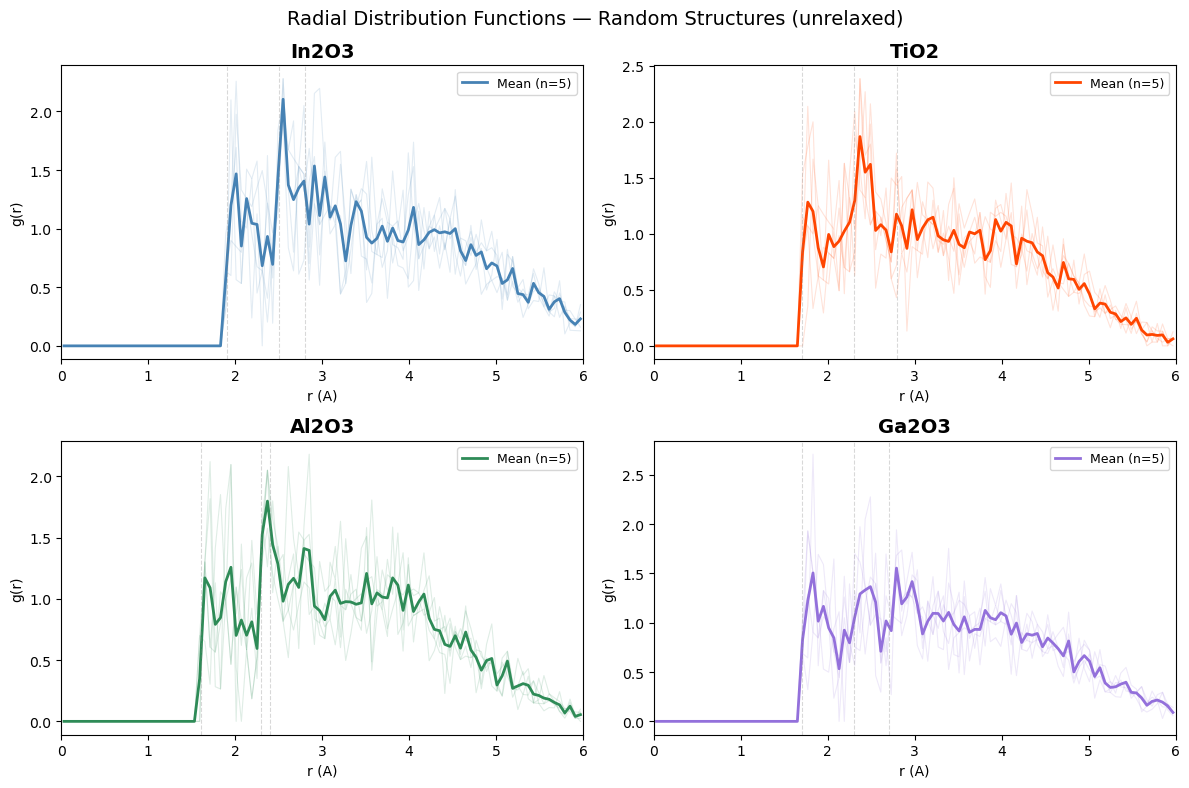

Saved -> rdf_random_all_systems.png


In [6]:
import matplotlib.pyplot as plt

def compute_rdf(atoms, rmax=6.0, nbins=100):
    """Compute the total radial distribution function."""
    d = atoms.get_all_distances(mic=True)
    np.fill_diagonal(d, np.inf)
    pairs = d[np.triu_indices_from(d, k=1)]
    pairs = pairs[pairs < rmax]
    hist, edges = np.histogram(pairs, bins=nbins, range=(0, rmax))
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]
    n = len(atoms)
    vol = atoms.get_volume()
    rho = n / vol
    # Normalise: g(r) = hist / (N_pairs * shell_vol * rho)
    n_pairs = n * (n - 1) / 2
    shell_vol = 4 * np.pi * r**2 * dr
    g_r = hist * vol / (n_pairs * shell_vol)
    return r, g_r


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = {"In2O3": "steelblue", "TiO2": "orangered", "Al2O3": "seagreen", "Ga2O3": "mediumpurple"}

for ax, (name, structures) in zip(axes.flat, all_structures.items()):
    # Plot all 20 RDFs as thin lines
    for i, atoms in enumerate(structures):
        r, g = compute_rdf(atoms)
        ax.plot(r, g, color=colors[name], alpha=0.15, lw=0.8)
    
    # Plot the mean RDF as a thick line
    rdfs = [compute_rdf(a)[1] for a in structures]
    r = compute_rdf(structures[0])[0]
    mean_rdf = np.mean(rdfs, axis=0)
    ax.plot(r, mean_rdf, color=colors[name], lw=2, label=f"Mean (n={len(structures)})")
    
    # Mark minsep values
    for pair, dist in systems[name]["minsep"].items():
        ax.axvline(dist, color="gray", ls="--", alpha=0.3, lw=0.8)
    
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel("r (A)")
    ax.set_ylabel("g(r)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 6)

fig.suptitle("Radial Distribution Functions — Random Structures (unrelaxed)", fontsize=14)
plt.tight_layout()
plt.savefig("rdf_random_all_systems.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> rdf_random_all_systems.png")

---
## 1.2 Optimise structures with MACE

The random structures have correct density and minimum separations, but they
are **not** energy-minimised. The atomic positions are physically unrealistic
until we relax them with a force field.

Here we take the 10 In₂O₃ structures from step 1.1 and optimise each one
using MACE-MPA-0. You can substitute any supported backend (CHGNet, M3GNet)
by changing the `model` argument in `get_calculator()`.

**Requirements:** `pip install mace-torch` (uses CPU if no GPU available)

In [7]:
from amorphgen.utils import get_calculator

# Load the MACE calculator (first call downloads the model ~100 MB)
calc = get_calculator(model="mace-mpa-0", device="cpu")
print("Calculator loaded.")

/Users/c.kaewmeechai@bham.ac.uk/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/Users/c.kaewmeechai@bham.ac.uk/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


[MACE] Loading foundation model 'mace-mpa-0' → mace_mp(model='medium-mpa-0')
Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/c.kaewmeechai@bham.ac.uk/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Calculator loaded.


In [8]:
from ase.optimize import LBFGS
from ase.filters import UnitCellFilter
from ase.io import write

system_name = "In2O3"
structures = all_structures[system_name]
relaxed_structures = []

out_dir = f"relaxed_{system_name}"
os.makedirs(out_dir, exist_ok=True)

print(f"Optimising {len(structures)} {system_name} structures with MACE...\n")

for i, atoms in enumerate(structures):
    atoms.calc = calc
    
    # Energy before relaxation
    e_before = atoms.get_potential_energy()
    
    # Relax with UnitCellFilter (optimises both positions and cell)
    ucf = UnitCellFilter(atoms)
    opt = LBFGS(ucf, logfile=None)
    opt.run(fmax=0.05, steps=200)
    
    e_after = atoms.get_potential_energy()
    relaxed_structures.append(atoms.copy())
    
    # Save relaxed structure
    write(f"{out_dir}/{system_name}_relaxed_{i:03d}.extxyz", atoms, format="extxyz")
    write(f"{out_dir}/{system_name}_relaxed_{i:03d}.cif", atoms)
    write(f"{out_dir}/{system_name}_relaxed_{i:03d}.vasp", atoms, format="vasp")
    
    de = (e_after - e_before) / len(atoms)
    print(f"  [{i+1:2d}/{len(structures)}]  E: {e_before/len(atoms):8.4f} -> {e_after/len(atoms):8.4f} eV/atom  (dE = {de:+.4f})")

print(f"\nDone! Relaxed structures saved to {out_dir}/")

Optimising 5 In2O3 structures with MACE...

  [ 1/5]  E:  -4.5026 ->  -5.4949 eV/atom  (dE = -0.9922)
  [ 2/5]  E:  -4.4069 ->  -5.4540 eV/atom  (dE = -1.0471)
  [ 3/5]  E:  -4.3847 ->  -5.4586 eV/atom  (dE = -1.0739)
  [ 4/5]  E:  -4.2506 ->  -5.4462 eV/atom  (dE = -1.1955)
  [ 5/5]  E:  -4.4014 ->  -5.4446 eV/atom  (dE = -1.0432)

Done! Relaxed structures saved to relaxed_In2O3/


### Compare RDF: before and after relaxation

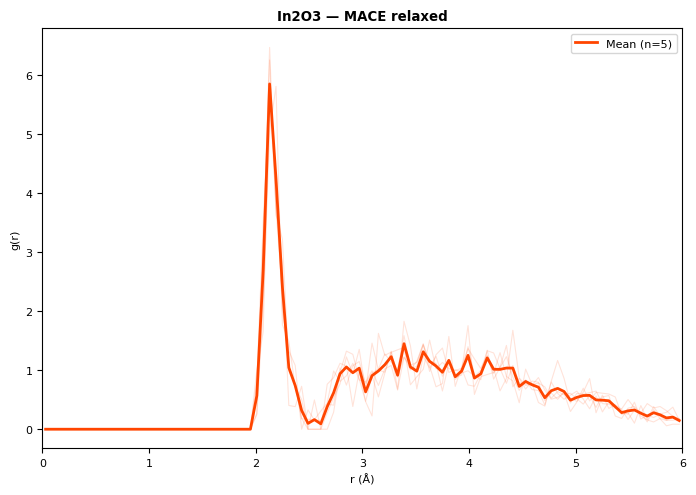

Saved -> rdf_relaxed_In2O3.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for atoms in relaxed_structures:
    r, g = compute_rdf(atoms)
    ax.plot(r, g, color="orangered", alpha=0.15, lw=0.8)

r = compute_rdf(relaxed_structures[0])[0]
mean_rdf = np.mean([compute_rdf(a)[1] for a in relaxed_structures], axis=0)
ax.plot(r, mean_rdf, color="orangered", lw=2, label=f"Mean (n={len(relaxed_structures)})")

ax.set_title(f"{system_name} — MACE relaxed", fontweight="bold")
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_xlim(0, 6)
ax.legend()
plt.tight_layout()
plt.savefig(f"rdf_relaxed_{system_name}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> rdf_relaxed_{system_name}.png")

### Compare energy distribution

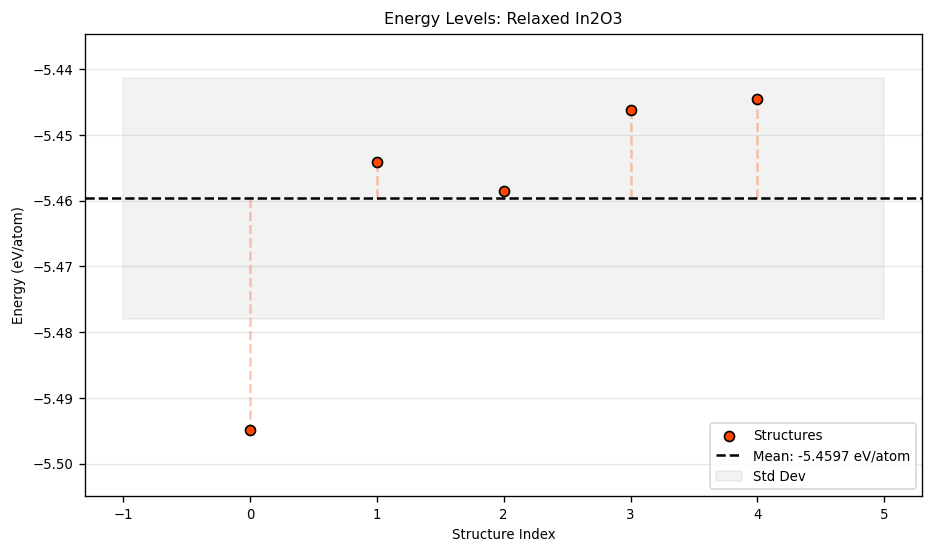

In [10]:
# Re-attach calculator and compute energies
for a in relaxed_structures:
    a.calc = calc

energies = [a.get_potential_energy() / len(a) for a in relaxed_structures]
mean_e = np.mean(energies)
std_e = np.std(energies)

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.scatter(range(len(energies)), energies, color="orangered", edgecolor="black", zorder=3, label="Structures")
ax.vlines(range(len(energies)), mean_e, energies, color="orangered", alpha=0.3, linestyles='--')
ax.axhline(mean_e, color="black", ls="--", lw=1.5, label=f"Mean: {mean_e:.4f} eV/atom")
ax.fill_between([-1, len(energies)], mean_e - std_e, mean_e + std_e, color="gray", alpha=0.1, label="Std Dev")
ax.set_ylim(np.min(energies) - 0.01, np.max(energies) + 0.01)
ax.set_ylabel("Energy (eV/atom)")
ax.set_xlabel("Structure Index")
ax.set_title(f"Energy Levels: Relaxed {system_name}")
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.show()

### Coordination number analysis

A key structural descriptor for amorphous oxides is the coordination number (CN).
In crystalline In₂O₃ (bixbyite), In is 6-coordinated by O. In the amorphous
phase, the CN distribution broadens, typically centring around 5–6.

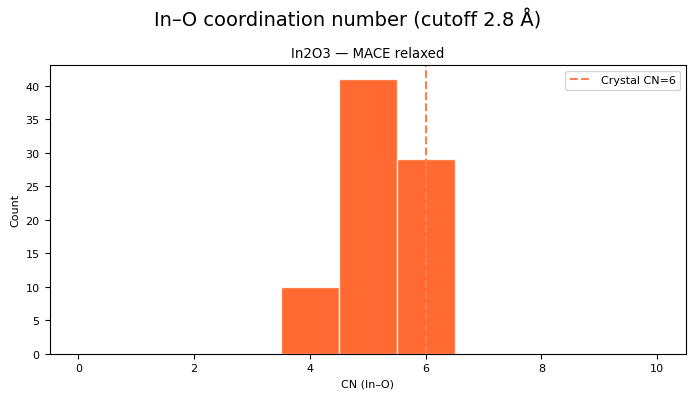

Relaxed — mean CN: 5.24 ± 0.66
Crystal — CN = 6 (octahedral)


In [11]:
from ase.neighborlist import neighbor_list

def coordination_numbers(atoms, central, neighbour, cutoff):
    """Compute CN of 'central' atoms surrounded by 'neighbour' atoms."""
    i_arr, j_arr = neighbor_list('ij', atoms, cutoff)
    syms = np.array(atoms.get_chemical_symbols())
    
    central_idx = np.where(syms == central)[0]
    cn = np.zeros(len(central_idx), dtype=int)
    
    for k, ci in enumerate(central_idx):
        mask = (i_arr == ci) & (syms[j_arr] == neighbour)
        cn[k] = np.sum(mask)
    
    return cn

cutoff_InO = 2.8  # Å — first coordination shell

fig, ax = plt.subplots(figsize=(7, 4))

cn_all_relaxed = []
for atoms in relaxed_structures:
    cn = coordination_numbers(atoms, "In", "O", cutoff_InO)
    cn_all_relaxed.extend(cn)

ax.hist(cn_all_relaxed, bins=range(0, 12), align="left",
        color="orangered", edgecolor="white", alpha=0.8)
ax.axvline(6, ls="--", color="coral", label="Crystal CN=6")
ax.set_xlabel("CN (In–O)")
ax.set_ylabel("Count")
ax.set_title(f"{system_name} — MACE relaxed")
ax.legend()
ax.set_xlim(-0.5, 10.5)

fig.suptitle(f"In–O coordination number (cutoff {cutoff_InO} Å)", fontsize=14)
plt.tight_layout()
plt.savefig(f"cn_relaxed_{system_name}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Relaxed — mean CN: {np.mean(cn_all_relaxed):.2f} ± {np.std(cn_all_relaxed):.2f}")
print(f"Crystal — CN = 6 (octahedral)")

### Bond angle distribution (O–In–O)

The O–In–O bond angle distribution provides insight into the local geometry.
In crystalline bixbyite In₂O₃, the octahedral environment gives angles
centred around 90° and 180°. Amorphous phases show broader distributions.

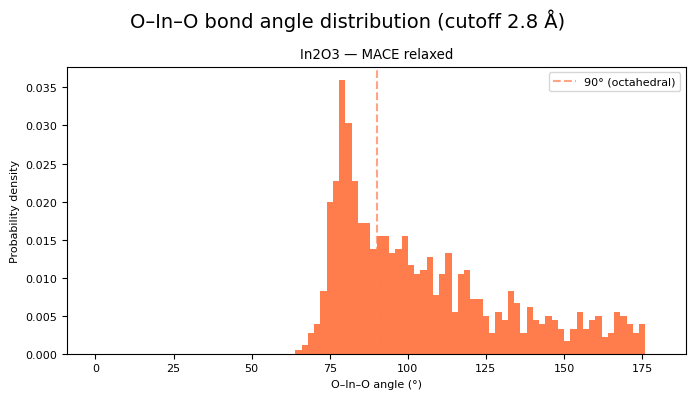

In [12]:
def bond_angles(atoms, central, neighbour, cutoff):
    """Compute neighbour-central-neighbour angles."""
    i_arr, j_arr, d_arr, D_arr = neighbor_list('ijdD', atoms, cutoff)
    syms = np.array(atoms.get_chemical_symbols())
    
    central_idx = np.where(syms == central)[0]
    angles = []
    
    for ci in central_idx:
        mask = (i_arr == ci) & (syms[j_arr] == neighbour)
        vecs = D_arr[mask]
        
        n_nbr = len(vecs)
        for a in range(n_nbr):
            for b in range(a + 1, n_nbr):
                cos_angle = np.dot(vecs[a], vecs[b]) / (
                    np.linalg.norm(vecs[a]) * np.linalg.norm(vecs[b])
                )
                cos_angle = np.clip(cos_angle, -1, 1)
                angles.append(np.degrees(np.arccos(cos_angle)))
    
    return np.array(angles)

fig, ax = plt.subplots(figsize=(7, 4))

all_angles_relaxed = []
for atoms in relaxed_structures:
    ang = bond_angles(atoms, "In", "O", cutoff_InO)
    all_angles_relaxed.extend(ang)

ax.hist(all_angles_relaxed, bins=90, range=(0, 180),
        color="orangered", edgecolor="none", alpha=0.7, density=True)
ax.axvline(90, ls="--", color="coral", alpha=0.7, label="90° (octahedral)")
ax.set_xlabel("O–In–O angle (°)")
ax.set_ylabel("Probability density")
ax.set_title(f"{system_name} — MACE relaxed")
ax.legend()

fig.suptitle(f"O–In–O bond angle distribution (cutoff {cutoff_InO} Å)", fontsize=14)
plt.tight_layout()
plt.savefig(f"angles_relaxed_{system_name}.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary statistics

In [13]:
# Print a summary table comparing unrelaxed vs relaxed
from ase.data import atomic_masses, atomic_numbers

def get_density(atoms):
    total_mass = sum(atomic_masses[atomic_numbers[s]] for s in atoms.get_chemical_symbols())
    vol_cm3 = atoms.get_volume() * 1e-24
    return (total_mass / 6.022e23) / vol_cm3

print(f"{'Property':<30s}  {'Unrelaxed':>12s}  {'MACE relaxed':>12s}  {'Crystal':>12s}")
print("-" * 70)

# Density
rho_unrelaxed = np.mean([get_density(a) for a in all_structures[system_name]])
rho_relaxed = np.mean([get_density(a) for a in relaxed_structures])
print(f"{'Density (g/cm³)':<30s}  {rho_unrelaxed:12.3f}  {rho_relaxed:12.3f}  {'7.12':>12s}")

# Energy
e_relaxed = np.mean([a.get_potential_energy()/len(a) for a in relaxed_structures])
e_std = np.std([a.get_potential_energy()/len(a) for a in relaxed_structures])
print(f"{'Energy (eV/atom)':<30s}  {'N/A':>12s}  {e_relaxed:12.4f}  {'—':>12s}")
print(f"{'Energy std (eV/atom)':<30s}  {'N/A':>12s}  {e_std:12.4f}  {'—':>12s}")

# CN
print(f"{'Mean In–O CN (relaxed)':<30s}  {'N/A':>12s}  {np.mean(cn_all_relaxed):12.2f}  {'6.00':>12s}")

print(f"\n{system_name}: {len(relaxed_structures)} structures generated and relaxed.")

Property                           Unrelaxed  MACE relaxed       Crystal
----------------------------------------------------------------------
Density (g/cm³)                        6.017         6.017          7.12
Energy (eV/atom)                         N/A       -5.4597             —
Energy std (eV/atom)                     N/A        0.0183             —
Mean In–O CN (relaxed)                   N/A          5.24          6.00

In2O3: 5 structures generated and relaxed.


---
## Note: Automated generation + relaxation via CLI

The two steps above (generate + optimise) can be done in one command
using the AmorphGen CLI:

```bash
# Generate 10 random In2O3 structures AND relax with MACE
amorphgen --random-gen \
    --composition In=16,O=24 \
    --target-density 5.5 \
    --n-structures 10 \
    --model mace-mpa-0 \
    --device cpu \
    --work-dir relaxed_In2O3

# Without relaxation (geometry only, instant)
amorphgen --random-gen \
    --composition In=16,O=24 \
    --target-density 5.5 \
    --n-structures 10 \
    --work-dir random_In2O3

# Use a different backend
amorphgen --random-gen --composition In=16,O=24 --target-density 5.5 --n-structures 10 --model chgnet --work-dir relaxed_chgnet
amorphgen --random-gen --composition In=16,O=24 --target-density 5.5 --n-structures 10 --model m3gnet --work-dir relaxed_m3gnet
```

Use `--relax --model mace-mpa-0` to enable relaxation.

---
## Note: Full 7-stage melt-and-quench pipeline

For production-quality amorphous structures, use the full melt-and-quench
pipeline instead of (or in addition to) random placement:

```bash
# Full 7-stage pipeline: optimise → pre-melt eq → melt → high-T eq → quench → low-T eq → final opt
amorphgen POSCAR --model mace-mpa-0 --device cuda

# With CHGNet
amorphgen POSCAR --model chgnet --device cuda

# Run specific stages only
amorphgen POSCAR --stages 1 2 3 4

# Resume from a checkpoint
amorphgen stage4_eq_high.extxyz --stages 5 6 7 --work-dir my_run
```

See the README and Tutorial 4 for full melt-and-quench examples.

---
## Output summary

After running this tutorial, you should have:

```
random_In2O3/       # 10 unrelaxed structures (.extxyz, .cif, .vasp)
random_TiO2/        # 10 unrelaxed structures
random_Al2O3/       # 10 unrelaxed structures
random_Ga2O3/       # 10 unrelaxed structures
relaxed_In2O3/      # 10 MACE-relaxed structures
rdf_random_all_systems.png
density_random_all_systems.png
rdf_comparison_In2O3.png
energy_distribution_In2O3.png
cn_comparison_In2O3.png
angles_In2O3.png
```

Open any `.cif` file in VESTA to visualise the structures.
Open any `.vasp` file as a POSCAR for VASP DFT calculations.

---
## References

1. **In₂O₃ (minsep & amorphous density):**
   Buchholz, D. B. *et al.* "The structure and properties of amorphous indium oxide."
   *Chemistry of Materials* **26**, 5401–5411 (2014). https://doi.org/10.1021/cm502689x

2. **In₂O₃ (amorphous density):**
   Nakamura, K. *et al.* "Structural analysis of amorphous In₂O₃ thin films."
   *Scientific Reports* **15**, 5849 (2025). https://doi.org/10.1038/s41598-025-89651-2

3. **TiO₂ (amorphous density):**
   Laube, M. *et al.* "Thickness dependent properties of amorphous TiO₂ thin films."
   *Thin Solid Films* **349**, 216–223 (1999). https://doi.org/10.1016/S0040-6090(99)00114-2

4. **Al₂O₃ (amorphous density):**
   Gorham, C. S. *et al.* "Density dependence of the room temperature thermal conductivity of amorphous alumina."
   *Thin Solid Films* **655**, 29–34 (2018). https://doi.org/10.1016/j.tsf.2018.03.080

5. **Ga₂O₃ (amorphous density):**
   Wang, T. *et al.* "Investigation of amorphous Ga₂O₃ thin films for electronics applications."
   *Journal of Electronic Materials* **54**, 1207–1215 (2025). https://doi.org/10.1007/s11664-024-11617-x

6. **Crystal structure data (minsep values):**
   Materials Project — mp-22598 (In₂O₃), mp-2657 (TiO₂), mp-1143 (Al₂O₃), mp-886 (β-Ga₂O₃).
   https://materialsproject.org